### Online Retail Analytics
#### Customer Analytics Using RFM
The objective of this notebook is to segment customers using the RFM (Recency, Frequency and Monetary Value) framework. This analysis helps identify high-value customers, understand purchasing behavior, and support data-driven marketing and customer retention strategies.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("data/cleaned/online_retail_cleaned.csv",dtype={"Invoice" :str})

In [14]:
df=df.dropna(subset=["Customer ID"])

In [16]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Month_Name,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,12,December,2009
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,December,2009
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,December,2009
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,12,December,2009
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,December,2009


In [17]:
df.shape

(779425, 12)

In [18]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Month', 'Month_Name',
       'Year'],
      dtype='str')

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1007912
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  str    
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
 8   Revenue      779425 non-null  float64
 9   Month        779425 non-null  int64  
 10  Month_Name   779425 non-null  str    
 11  Year         779425 non-null  int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 77.3 MB


In [20]:
# Convert InvoiceDate back to datetime
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

#### RFM Metric Calculation
In this section, the **Recency**, **Frequency**, and **Monetary (RFM)** metrics are calculated for each customer based on their purchase history.
- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Total number of unique orders placed by the customer.
- **Monetary:** Total revenue generated by the customer.

In [21]:
# snapshot date - the reference point for calculating recency
snapshot_date=df["InvoiceDate"].max()+pd.Timedelta(days=1)

In [22]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [23]:
# Calculating Recency, Frequency and Monetary for every customer
rfm=df.groupby("Customer ID").agg({"InvoiceDate": lambda x: (snapshot_date-x.max()).days,
                                  "Invoice": "nunique",
                                  "Revenue":"sum"})

In [24]:
type(rfm)

pandas.DataFrame

In [25]:
rfm.head()

,InvoiceDate,Invoice,Revenue
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [26]:
# Renaming rfm columns, as these names aren't business-friendly
rfm.columns=["Recency","Frequency","Monetary"]

In [27]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [28]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


#### RFM Scoring

In [29]:
# Creating Recency Score
rfm["R_Score"]=pd.qcut(rfm["Recency"],q=4,labels=[4,3,2,1])

In [30]:
# Creating Frequency Score
rfm["F_Score"]=pd.qcut(rfm["Frequency"].rank(method="first"),q=4,labels=[1,2,3,4])

In [31]:
# Creating Monetary Score
rfm["M_Score"]=pd.qcut(rfm["Monetary"],q=4,labels=[1,2,3,4])

In [32]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,326,12,77556.46,2,4,4
12347.0,2,8,4921.53,4,4,4
12348.0,75,5,2019.40,3,3,3
12349.0,19,4,4428.69,4,3,4
12350.0,310,1,334.40,2,1,1
12351.0,375,1,300.93,2,1,1
12352.0,36,10,2849.84,3,4,4
12353.0,204,2,406.76,2,2,2
12354.0,232,1,1079.40,2,1,3


#### Observation
Each customer has been assigned a Recency, Frequency, and Monetary score ranging from 1 to 4. A higher score indicates better customer behavior across all three metrics. For Recency, customers who purchased more recently receive higher scores.

#### Customer Segmentation

In [50]:
# Function to classify customers into business segments

In [33]:
def segment_customer(row):
    if row["R_Score"]>=3 and row["F_Score"]>=3 and row["M_Score"]>=3:
        return "Champion"
    elif row["F_Score"]>=3 and row["M_Score"]>=3:
        return "Loyal Customer"
    elif row["R_Score"]>=3:
        return "Potential Loyalist"
    elif row["R_Score"]==1:
        return "At Risk"
    else:
        return "Others"

In [34]:
# Assigning customer segments
rfm["Segment"]=rfm.apply(segment_customer,axis=1)

In [35]:
rfm.head(100)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,4,4,Loyal Customer
12347.0,2,8,4921.53,4,4,4,Champion
12348.0,75,5,2019.40,3,3,3,Champion
12349.0,19,4,4428.69,4,3,4,Champion
12350.0,310,1,334.40,2,1,1,Others
...,...,...,...,...,...,...,...
12442.0,3,1,172.06,4,1,1,Potential Loyalist
12443.0,732,1,485.31,1,1,2,At Risk
12444.0,21,5,5005.46,4,3,4,Champion


#### Segment Distribution

In [36]:
# Count customers in each segment
segment_counts=rfm["Segment"].value_counts()

In [37]:
segment_counts

Segment
Champion              1821
At Risk               1304
Potential Loyalist    1132
Others                 978
Loyal Customer         643
Name: count, dtype: int64

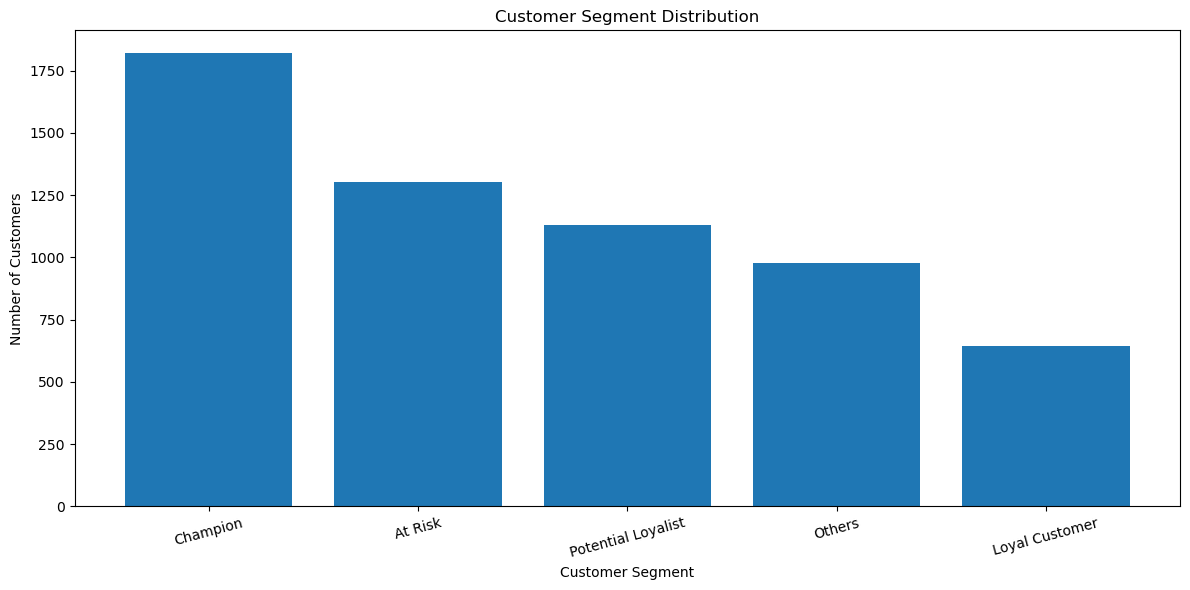

In [42]:
# Visualize customer segments
plt.figure(figsize=(12,6))
plt.bar(segment_counts.index,segment_counts.values)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/customer_segmentation.png",
dpi=300, bbox_inches="tight")
plt.show()

#### Business Recommendations
#### Assigning customer segments

#### Champions
These customers purchase frequently, spend the most, and have bought recently. They are the most valuable customers for the business.
**Recommendation**
- Reward with exclusive offers and loyalty programs.
- Provide early access to new products.
- Focus on retaining these customers through personalized experiences.

#### Loyal Customers
These customers purchase regularly and contribute significant revenue but may not always buy recently.
**Recommendation**
- Encourage continued engagement through reward points.
- Offer membership benefits and personalized discounts.
- Recommend complementary products based on purchase history.

#### Potential Loyalists
These customers have purchased recently but have not yet become frequent buyers.
**Recommendation**
- Send welcome offers and product recommendations.
- Encourage repeat purchases with limited-time discounts.
- Build long-term engagement through email campaigns.

#### At Risk Customers
These customers were previously active but have not purchased recently.
**Recommendation**
- Launch re-engagement campaigns.
- Provide special discounts or reminder emails.
- Identify reasons for inactivity and improve customer retention.

#### Others
These customers have relatively low purchasing activity and contribute less revenue.
**Recommendation**
- Include them in general promotional campaigns.
- Monitor future purchase behavior before investing in targeted marketing.

#### Conclusion
The RFM analysis successfully segmented customers based on their purchasing behavior.

The results identify the company's most valuable customers while also highlighting customer groups that may require retention or re-engagement strategies. These insights can support targeted marketing campaigns, improve customer loyalty, and maximize long-term business value.